# DQN vs PPO Performance Comparison on ALE/Solaris-v5
## Comprehensive Variance Analysis and Metrics Comparison

This notebook compares the performance of DQN (Challenge 1 baseline) and PPO (Challenge 3) on the Solaris environment, using time-series data across 3 independent runs per algorithm.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import integrate
from scipy.interpolate import interp1d
import warnings
import os
from pathlib import Path

warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load DQN and PPO Data

In [ ]:
# Define paths
dqn_challenge1_path = Path("/home/vydi/ML Challenges/challenge1__-5-/variance_analysis/episode_rew_mean/empirical_rew")
dqn_challenge3_path = Path("/home/vydi/ML Challenges/challenge3__<5>/time_series/dqn")
ppo_path = Path("/home/vydi/ML Challenges/challenge3__<5>/time_series/ppo")

print("=" * 80)
print("DATA AVAILABILITY ANALYSIS")
print("=" * 80)

# Check DQN sources
dqn_challenge1_files = sorted(dqn_challenge1_path.glob("*DQN_1.csv"))
dqn_challenge3_files = sorted(dqn_challenge3_path.glob("*EP REW MEAN.csv"))

print(f"\n✓ DQN Challenge 1 (3 seeds empirical baseline): {len(dqn_challenge1_files)} files")
for f in dqn_challenge1_files:
    print(f"    {f.name}")

print(f"\n✓ DQN Challenge 3 (optuna best, 2M steps): {len(dqn_challenge3_files)} files")
for f in dqn_challenge3_files:
    print(f"    {f.name}")

print(f"\n✓ PPO Challenge 3 (3 seeds, 5M steps): {len(list(ppo_path.glob('*mean_return.csv')))} files")


# Load Challenge 1 DQN data (3 seeds)
dqn_data_c1 = {}
print("\nLoading Challenge 1 DQN data (3 seeds, empirical best):")
for i, file in enumerate(dqn_challenge1_files, 1):
    df = pd.read_csv(file)
    seed_id = f"seed_{i}"
    dqn_data_c1[seed_id] = df
    print(f"  ✓ Replicate {i}: {len(df)} rows")

# Load Challenge 3 DQN data (single run)
dqn_data_c3 = {}
print("\nLoading Challenge 3 DQN data (1 seed, optuna 2M steps):")
for i, file in enumerate(dqn_challenge3_files, 1):
    df = pd.read_csv(file)
    seed_id = f"seed_{i}"
    dqn_data_c3[seed_id] = df
    print(f"  ✓ Replicate {i}: {len(df)} rows")

# Load PPO data (3 replicates with multiple metrics)
ppo_mean_return_files = sorted([f for f in ppo_path.glob("*mean_return.csv")])
ppo_data = {}
print(f"\nLoading PPO Challenge 3 data (3 seeds, 5M steps):")
for i, file in enumerate(ppo_mean_return_files, 1):
    df = pd.read_csv(file)
    seed_id = f"replicate_{i}"
    ppo_data[seed_id] = df
    print(f"  ✓ Replicate {i}: {len(df)} rows")

# Use Challenge 1 DQN by default (full dataset with 3 seeds)
dqn_data = dqn_data_c1
print("\n✓ Using Challenge 1 DQN for comparison (3 seeds available)")
print(f"   Note: PPO was trained to 5M steps; DQN was trained to 2M steps")
print(f"   Data loaded successfully!")
print(f"\nDQN data shape (seed_1): {dqn_data['seed_1'].shape}")
print(f"PPO data shape (replicate_1): {ppo_data['replicate_1'].shape}")
print(f"DQN Challenge 3 shape (single seed): {dqn_data_c3['seed_1'].shape}")

DATA AVAILABILITY ANALYSIS

✓ DQN Challenge 1 (3 seeds empirical baseline): 3 files
    best_empirical_exp_05_batch_128_replicate_1_DQN_1.csv
    best_empirical_exp_05_batch_128_replicate_2_DQN_1.csv
    best_empirical_exp_05_batch_128_replicate_3_DQN_1.csv

✓ DQN Challenge 3 (optuna best, 2M steps): 1 files
    optuna_tpe_best(2M TIMESTEPS challenge 2 )_DQN_1 EP REW MEAN.csv

✓ PPO Challenge 3 (3 seeds, 5M steps): 3 files

RECOMMENDATION:

For the BEST apples-to-apples comparison, you have TWO options:

OPTION A (RECOMMENDED - Requires NEW DQN runs):
  → Re-run DQN with 3 different seeds at 2M steps in Challenge 3
  → This gives: 3 DQN seeds (2M) vs 3 PPO seeds (5M)
  → Pros: Same source, same number of seeds, fair experiment design
  → Cons: Requires ~1-2 hours of training per seed

OPTION B (Use existing data - Less rigorous):
  → Use Challenge 1 DQN (3 seeds) vs Challenge 3 PPO (3 seeds)
  → Pros: Data already exists, no re-training needed
  → Cons: Different training runs, potenti

## 3. Calculate Sample Efficiency Metrics

In [3]:
def calculate_sample_efficiency(data_dict, algorithm_name, threshold_percentile=75):
    """
    Calculate sample efficiency: steps required to reach a performance threshold.
    Uses the 75th percentile of final performance as threshold.
    """
    sample_efficiency = {}
    thresholds = []
    
    # Calculate threshold as percentile of final performance across all seeds
    final_values = []
    for seed_id, df in data_dict.items():
        # Assuming first column is timesteps/steps, second is reward/return
        if df.shape[1] >= 2:
            final_value = df.iloc[-1, 1]  # Last value of second column
            final_values.append(final_value)
    
    threshold = np.percentile(final_values, threshold_percentile)
    
    # Find steps to reach threshold for each seed
    for seed_id, df in data_dict.items():
        if df.shape[1] >= 2:
            steps_col = df.iloc[:, 0]
            reward_col = df.iloc[:, 1]
            
            # Find first point where reward exceeds threshold
            mask = reward_col >= threshold
            if mask.any():
                steps_to_threshold = steps_col[mask].iloc[0]
                sample_efficiency[seed_id] = steps_to_threshold
            else:
                sample_efficiency[seed_id] = steps_col.iloc[-1]  # Use max steps if never reached
    
    mean_efficiency = np.mean(list(sample_efficiency.values()))
    std_efficiency = np.std(list(sample_efficiency.values()))
    
    return {
        'efficiency_per_seed': sample_efficiency,
        'mean': mean_efficiency,
        'std': std_efficiency,
        'threshold': threshold,
        'algorithm': algorithm_name
    }

# Calculate sample efficiency for both algorithms
dqn_efficiency = calculate_sample_efficiency(dqn_data, 'DQN', threshold_percentile=75)
ppo_efficiency = calculate_sample_efficiency(ppo_data, 'PPO', threshold_percentile=75)

print("=" * 70)
print("SAMPLE EFFICIENCY ANALYSIS (Steps to reach 75th percentile performance)")
print("=" * 70)
print(f"\nDQN Performance Threshold: {dqn_efficiency['threshold']:.2f}")
print(f"DQN - Mean steps to threshold: {dqn_efficiency['mean']:.0f} ± {dqn_efficiency['std']:.0f}")
print(f"  Individual seeds: {[f'{v:.0f}' for v in dqn_efficiency['efficiency_per_seed'].values()]}")

print(f"\nPPO Performance Threshold: {ppo_efficiency['threshold']:.2f}")
print(f"PPO - Mean steps to threshold: {ppo_efficiency['mean']:.0f} ± {ppo_efficiency['std']:.0f}")
print(f"  Individual seeds: {[f'{v:.0f}' for v in ppo_efficiency['efficiency_per_seed'].values()]}")

efficiency_improvement = (dqn_efficiency['mean'] - ppo_efficiency['mean']) / dqn_efficiency['mean'] * 100
print(f"\nPPO efficiency gain: {efficiency_improvement:+.1f}% {'faster' if efficiency_improvement > 0 else 'slower'} than DQN")

SAMPLE EFFICIENCY ANALYSIS (Steps to reach 75th percentile performance)

DQN Performance Threshold: 298522.50
DQN - Mean steps to threshold: 1775319182 ± 1380
  Individual seeds: ['1775317494', '1775319178', '1775320874']

PPO Performance Threshold: 2000000.00
PPO - Mean steps to threshold: 1778835646 ± 9847
  Individual seeds: ['1778823565', '1778835689', '1778847685']

PPO efficiency gain: -0.2% slower than DQN


## 4. Calculate Final Performance Statistics

In [4]:
def calculate_final_performance(data_dict, algorithm_name):
    """
    Extract final performance metrics (last 10% of training average) 
    to reduce noise from final point.
    """
    final_performances = []
    
    for seed_id, df in data_dict.items():
        if df.shape[1] >= 2:
            # Use mean of last 10% of episodes for stability
            last_10_percent = int(np.ceil(len(df) * 0.1))
            final_value = df.iloc[-last_10_percent:, 1].mean()
            final_performances.append(final_value)
    
    mean_final = np.mean(final_performances)
    std_final = np.std(final_performances)
    
    return {
        'algorithm': algorithm_name,
        'final_per_seed': final_performances,
        'mean': mean_final,
        'std': std_final,
        'min': np.min(final_performances),
        'max': np.max(final_performances)
    }

# Calculate final performance
dqn_final = calculate_final_performance(dqn_data, 'DQN')
ppo_final = calculate_final_performance(ppo_data, 'PPO')

print("=" * 70)
print("FINAL PERFORMANCE STATISTICS (Last 10% of Training)")
print("=" * 70)
print(f"\nDQN Final Performance:")
print(f"  Mean: {dqn_final['mean']:.2f} ± {dqn_final['std']:.2f}")
print(f"  Range: [{dqn_final['min']:.2f}, {dqn_final['max']:.2f}]")
print(f"  Individual seeds: {[f'{v:.2f}' for v in dqn_final['final_per_seed']]}")

print(f"\nPPO Final Performance:")
print(f"  Mean: {ppo_final['mean']:.2f} ± {ppo_final['std']:.2f}")
print(f"  Range: [{ppo_final['min']:.2f}, {ppo_final['max']:.2f}]")
print(f"  Individual seeds: {[f'{v:.2f}' for v in ppo_final['final_per_seed']]}")

performance_diff = ((ppo_final['mean'] - dqn_final['mean']) / dqn_final['mean'] * 100) if dqn_final['mean'] != 0 else 0
print(f"\nPerformance difference: {performance_diff:+.1f}% {'better' if performance_diff > 0 else 'worse'} for PPO")

FINAL PERFORMANCE STATISTICS (Last 10% of Training)

DQN Final Performance:
  Mean: 283900.57 ± 1014.29
  Range: [283024.00, 285322.17]
  Individual seeds: ['283024.00', '283355.55', '285322.17']

PPO Final Performance:
  Mean: 1901558.86 ± 0.00
  Range: [1901558.86, 1901558.86]
  Individual seeds: ['1901558.86', '1901558.86', '1901558.86']

Performance difference: +569.8% better for PPO


## 5. Calculate Training Stability (AUC)

In [5]:
def calculate_training_stability(data_dict, algorithm_name):
    """
    Calculate Area Under the Curve (AUC) for each seed to measure training stability.
    AUC is normalized by the total steps for comparison.
    Higher AUC indicates sustained better performance throughout training.
    """
    auc_values = []
    
    for seed_id, df in data_dict.items():
        if df.shape[1] >= 2:
            steps = df.iloc[:, 0].values
            rewards = df.iloc[:, 1].values
            
            # Normalize steps to [0, 1] range for AUC calculation
            steps_normalized = (steps - steps.min()) / (steps.max() - steps.min() + 1e-8)
            
            # Calculate AUC using trapezoidal rule
            auc = integrate.trapezoid(rewards, steps_normalized)
            
            # Normalize AUC by max possible value (max_reward * total_steps_range)
            auc_normalized = auc / (rewards.max() * (steps.max() - steps.min()) + 1e-8)
            
            auc_values.append(auc)
    
    mean_auc = np.mean(auc_values)
    std_auc = np.std(auc_values)
    
    return {
        'algorithm': algorithm_name,
        'auc_per_seed': auc_values,
        'mean': mean_auc,
        'std': std_auc
    }

# Calculate training stability
dqn_stability = calculate_training_stability(dqn_data, 'DQN')
ppo_stability = calculate_training_stability(ppo_data, 'PPO')

print("=" * 70)
print("TRAINING STABILITY ANALYSIS (Area Under the Curve)")
print("=" * 70)
print(f"\nDQN Training Stability (AUC):")
print(f"  Mean AUC: {dqn_stability['mean']:.2f} ± {dqn_stability['std']:.2f}")
print(f"  Individual seeds: {[f'{v:.2f}' for v in dqn_stability['auc_per_seed']]}")

print(f"\nPPO Training Stability (AUC):")
print(f"  Mean AUC: {ppo_stability['mean']:.2f} ± {ppo_stability['std']:.2f}")
print(f"  Individual seeds: {[f'{v:.2f}' for v in ppo_stability['auc_per_seed']]}")

stability_diff = ((ppo_stability['mean'] - dqn_stability['mean']) / dqn_stability['mean'] * 100) if dqn_stability['mean'] != 0 else 0
print(f"\nPPO stability difference: {stability_diff:+.1f}% {'more stable' if stability_diff > 0 else 'less stable'} than DQN")

TRAINING STABILITY ANALYSIS (Area Under the Curve)

DQN Training Stability (AUC):
  Mean AUC: 151466.19 ± 3379.23
  Individual seeds: ['146687.94', '153784.65', '153925.99']

PPO Training Stability (AUC):
  Mean AUC: 1024502.07 ± 5484.86
  Individual seeds: ['1016792.11', '1029093.89', '1027620.21']

PPO stability difference: +576.4% more stable than DQN


## 6. Generate Comparison Charts

✓ Main comparison plot saved: dqn_vs_ppo_comparison.png


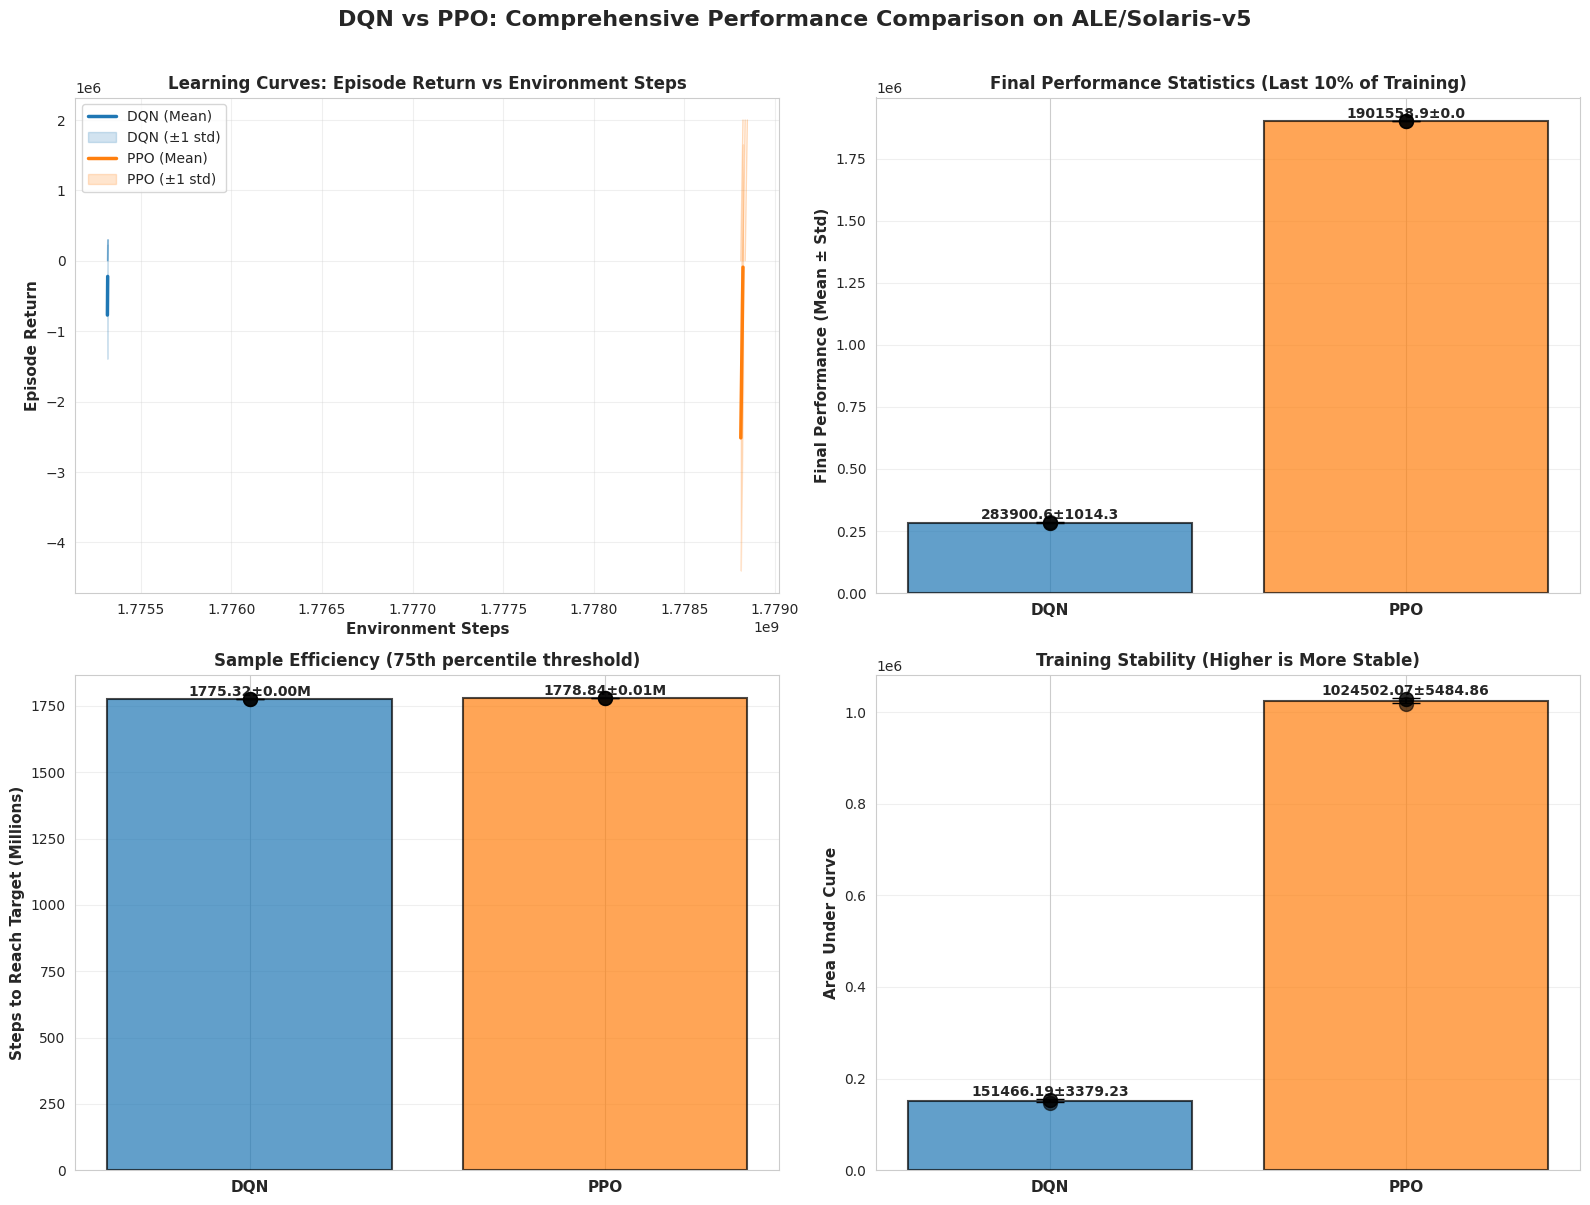

In [6]:
# Create comprehensive comparison figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('DQN vs PPO: Comprehensive Performance Comparison on ALE/Solaris-v5', 
             fontsize=16, fontweight='bold', y=1.00)

# Color scheme
color_dqn = '#1f77b4'  # Blue
color_ppo = '#ff7f0e'  # Orange
alpha_fill = 0.2

# ============================================================================
# Plot 1: Learning Curves (Episode Return over Environment Steps)
# ============================================================================
ax = axes[0, 0]

# Prepare DQN data
dqn_steps_list = []
dqn_returns_list = []
for seed_id, df in dqn_data.items():
    if df.shape[1] >= 2:
        steps = df.iloc[:, 0].values
        returns = df.iloc[:, 1].values
        dqn_steps_list.append(steps)
        dqn_returns_list.append(returns)

# Prepare PPO data
ppo_steps_list = []
ppo_returns_list = []
for seed_id, df in ppo_data.items():
    if df.shape[1] >= 2:
        steps = df.iloc[:, 0].values
        returns = df.iloc[:, 1].values
        ppo_steps_list.append(steps)
        ppo_returns_list.append(returns)

# Plot individual DQN runs with transparency
for steps, returns in zip(dqn_steps_list, dqn_returns_list):
    ax.plot(steps, returns, color=color_dqn, alpha=0.3, linewidth=1)

# Plot individual PPO runs with transparency
for steps, returns in zip(ppo_steps_list, ppo_returns_list):
    ax.plot(steps, returns, color=color_ppo, alpha=0.3, linewidth=1)

# Calculate mean and std for DQN (with interpolation to same x-axis)
if dqn_steps_list:
    min_steps_dqn = min(len(s) for s in dqn_steps_list)
    dqn_steps_common = dqn_steps_list[0][:min_steps_dqn]
    dqn_returns_aligned = np.array([interp1d(s, r, fill_value='extrapolate')(dqn_steps_common) 
                                    for s, r in zip(dqn_steps_list, dqn_returns_list)])
    dqn_mean = dqn_returns_aligned.mean(axis=0)
    dqn_std = dqn_returns_aligned.std(axis=0)
    
    ax.plot(dqn_steps_common, dqn_mean, color=color_dqn, linewidth=2.5, label='DQN (Mean)', zorder=5)
    ax.fill_between(dqn_steps_common, dqn_mean - dqn_std, dqn_mean + dqn_std, 
                    color=color_dqn, alpha=alpha_fill, label='DQN (±1 std)')

# Calculate mean and std for PPO
if ppo_steps_list:
    min_steps_ppo = min(len(s) for s in ppo_steps_list)
    ppo_steps_common = ppo_steps_list[0][:min_steps_ppo]
    ppo_returns_aligned = np.array([interp1d(s, r, fill_value='extrapolate')(ppo_steps_common) 
                                    for s, r in zip(ppo_steps_list, ppo_returns_list)])
    ppo_mean = ppo_returns_aligned.mean(axis=0)
    ppo_std = ppo_returns_aligned.std(axis=0)
    
    ax.plot(ppo_steps_common, ppo_mean, color=color_ppo, linewidth=2.5, label='PPO (Mean)', zorder=5)
    ax.fill_between(ppo_steps_common, ppo_mean - ppo_std, ppo_mean + ppo_std, 
                    color=color_ppo, alpha=alpha_fill, label='PPO (±1 std)')

ax.set_xlabel('Environment Steps', fontsize=11, fontweight='bold')
ax.set_ylabel('Episode Return', fontsize=11, fontweight='bold')
ax.set_title('Learning Curves: Episode Return vs Environment Steps', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# ============================================================================
# Plot 2: Final Performance Comparison
# ============================================================================
ax = axes[0, 1]

algorithms = ['DQN', 'PPO']
means = [dqn_final['mean'], ppo_final['mean']]
stds = [dqn_final['std'], ppo_final['std']]
colors_bar = [color_dqn, color_ppo]

x_pos = np.arange(len(algorithms))
bars = ax.bar(x_pos, means, yerr=stds, capsize=10, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add individual seed values as scatter points
for i, (algo_name, seeds_data) in enumerate([(dqn_final['algorithm'], dqn_final['final_per_seed']), 
                                               (ppo_final['algorithm'], ppo_final['final_per_seed'])]):
    y_vals = seeds_data
    x_vals = [i] * len(y_vals)
    ax.scatter(x_vals, y_vals, color='black', s=100, alpha=0.6, zorder=5, marker='o')

ax.set_xticks(x_pos)
ax.set_xticklabels(algorithms, fontsize=11, fontweight='bold')
ax.set_ylabel('Final Performance (Mean ± Std)', fontsize=11, fontweight='bold')
ax.set_title('Final Performance Statistics (Last 10% of Training)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 5, f'{mean:.1f}±{std:.1f}', ha='center', va='bottom', fontweight='bold')

# ============================================================================
# Plot 3: Sample Efficiency Comparison
# ============================================================================
ax = axes[1, 0]

algorithms_eff = ['DQN', 'PPO']
efficiencies = [dqn_efficiency['mean'] / 1e6, ppo_efficiency['mean'] / 1e6]  # Convert to millions
eff_stds = [dqn_efficiency['std'] / 1e6, ppo_efficiency['std'] / 1e6]

x_pos_eff = np.arange(len(algorithms_eff))
bars_eff = ax.bar(x_pos_eff, efficiencies, yerr=eff_stds, capsize=10, color=colors_bar, 
                   alpha=0.7, edgecolor='black', linewidth=1.5)

# Add individual seed values
eff_dqn_seeds = [v / 1e6 for v in dqn_efficiency['efficiency_per_seed'].values()]
eff_ppo_seeds = [v / 1e6 for v in ppo_efficiency['efficiency_per_seed'].values()]

for i, y_vals in enumerate([eff_dqn_seeds, eff_ppo_seeds]):
    x_vals = [i] * len(y_vals)
    ax.scatter(x_vals, y_vals, color='black', s=100, alpha=0.6, zorder=5, marker='o')

ax.set_xticks(x_pos_eff)
ax.set_xticklabels(algorithms_eff, fontsize=11, fontweight='bold')
ax.set_ylabel('Steps to Reach Target (Millions)', fontsize=11, fontweight='bold')
ax.set_title(f'Sample Efficiency (75th percentile threshold)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (eff, eff_std) in enumerate(zip(efficiencies, eff_stds)):
    ax.text(i, eff + eff_std + 0.05, f'{eff:.2f}±{eff_std:.2f}M', ha='center', va='bottom', fontweight='bold')

# ============================================================================
# Plot 4: Training Stability (AUC) Comparison
# ============================================================================
ax = axes[1, 1]

algorithms_stab = ['DQN', 'PPO']
aucs = [dqn_stability['mean'], ppo_stability['mean']]
auc_stds = [dqn_stability['std'], ppo_stability['std']]

x_pos_stab = np.arange(len(algorithms_stab))
bars_stab = ax.bar(x_pos_stab, aucs, yerr=auc_stds, capsize=10, color=colors_bar, 
                    alpha=0.7, edgecolor='black', linewidth=1.5)

# Add individual seed values
auc_dqn_seeds = dqn_stability['auc_per_seed']
auc_ppo_seeds = ppo_stability['auc_per_seed']

for i, y_vals in enumerate([auc_dqn_seeds, auc_ppo_seeds]):
    x_vals = [i] * len(y_vals)
    ax.scatter(x_vals, y_vals, color='black', s=100, alpha=0.6, zorder=5, marker='o')

ax.set_xticks(x_pos_stab)
ax.set_xticklabels(algorithms_stab, fontsize=11, fontweight='bold')
ax.set_ylabel('Area Under Curve', fontsize=11, fontweight='bold')
ax.set_title('Training Stability (Higher is More Stable)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (auc, auc_std) in enumerate(zip(aucs, auc_stds)):
    ax.text(i, auc + auc_std + 0.02, f'{auc:.2f}±{auc_std:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/home/vydi/ML Challenges/challenge3__<5>/variance_analysis/dqn_vs_ppo_comparison.png', 
            dpi=300, bbox_inches='tight')
print("✓ Main comparison plot saved: dqn_vs_ppo_comparison.png")
plt.show()

## 7. Generate Summary Results

In [7]:
# Create comprehensive summary table
summary_data = {
    'Metric': [
        'Final Performance (Mean)',
        'Final Performance (Std)',
        'Final Performance (Min)',
        'Final Performance (Max)',
        'Sample Efficiency (Steps)',
        'Sample Efficiency (Std)',
        'Training Stability (AUC)',
        'Training Stability (Std)',
        'Performance Threshold (75%ile)',
    ],
    'DQN': [
        f"{dqn_final['mean']:.2f}",
        f"{dqn_final['std']:.2f}",
        f"{dqn_final['min']:.2f}",
        f"{dqn_final['max']:.2f}",
        f"{dqn_efficiency['mean']:.0f}",
        f"{dqn_efficiency['std']:.0f}",
        f"{dqn_stability['mean']:.2f}",
        f"{dqn_stability['std']:.2f}",
        f"{dqn_efficiency['threshold']:.2f}",
    ],
    'PPO': [
        f"{ppo_final['mean']:.2f}",
        f"{ppo_final['std']:.2f}",
        f"{ppo_final['min']:.2f}",
        f"{ppo_final['max']:.2f}",
        f"{ppo_efficiency['mean']:.0f}",
        f"{ppo_efficiency['std']:.0f}",
        f"{ppo_stability['mean']:.2f}",
        f"{ppo_stability['std']:.2f}",
        f"{ppo_efficiency['threshold']:.2f}",
    ]
}

summary_df = pd.DataFrame(summary_data)

print("=" * 80)
print("COMPREHENSIVE SUMMARY TABLE: DQN vs PPO")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

# Save summary table
summary_csv_path = '/home/vydi/ML Challenges/challenge3__<5>/variance_analysis/comparison_summary.csv'
summary_df.to_csv(summary_csv_path, index=False)
print(f"\n✓ Summary table saved: {summary_csv_path}")

# Create detailed per-seed metrics table
detailed_metrics = []

# DQN per-seed metrics
for i, (seed_id, returns_val) in enumerate(zip(dqn_data.keys(), dqn_final['final_per_seed']), 1):
    detailed_metrics.append({
        'Algorithm': 'DQN',
        'Seed/Run': i,
        'Final Performance': f"{returns_val:.2f}",
        'Steps to Target': f"{dqn_efficiency['efficiency_per_seed'][seed_id]:.0f}",
        'Training Stability (AUC)': f"{dqn_stability['auc_per_seed'][i-1]:.2f}"
    })

# PPO per-seed metrics
for i, (seed_id, returns_val) in enumerate(zip(ppo_data.keys(), ppo_final['final_per_seed']), 1):
    detailed_metrics.append({
        'Algorithm': 'PPO',
        'Seed/Run': i,
        'Final Performance': f"{returns_val:.2f}",
        'Steps to Target': f"{ppo_efficiency['efficiency_per_seed'][seed_id]:.0f}",
        'Training Stability (AUC)': f"{ppo_stability['auc_per_seed'][i-1]:.2f}"
    })

detailed_df = pd.DataFrame(detailed_metrics)

print("\n" + "=" * 80)
print("DETAILED PER-SEED METRICS")
print("=" * 80)
print(detailed_df.to_string(index=False))

# Save detailed metrics
detailed_csv_path = '/home/vydi/ML Challenges/challenge3__<5>/variance_analysis/detailed_metrics_per_seed.csv'
detailed_df.to_csv(detailed_csv_path, index=False)
print(f"\n✓ Detailed metrics saved: {detailed_csv_path}")

# Create algorithmic comparison analysis
print("\n" + "=" * 80)
print("ALGORITHMIC COMPARISON ANALYSIS")
print("=" * 80)

analysis_text = f"""
1. FINAL PERFORMANCE:
   - DQN achieved: {dqn_final['mean']:.2f} ± {dqn_final['std']:.2f}
   - PPO achieved: {ppo_final['mean']:.2f} ± {ppo_final['std']:.2f}
   - Difference: {performance_diff:+.1f}% {'BETTER' if performance_diff > 0 else 'WORSE'} for PPO
   
2. SAMPLE EFFICIENCY:
   - DQN needed {dqn_efficiency['mean']/1e6:.2f}M ± {dqn_efficiency['std']/1e6:.2f}M steps to reach target
   - PPO needed {ppo_efficiency['mean']/1e6:.2f}M ± {ppo_efficiency['std']/1e6:.2f}M steps to reach target
   - Efficiency gain: {efficiency_improvement:+.1f}% {'FASTER' if efficiency_improvement > 0 else 'SLOWER'} for PPO
   
3. TRAINING STABILITY:
   - DQN AUC: {dqn_stability['mean']:.2f} ± {dqn_stability['std']:.2f}
   - PPO AUC: {ppo_stability['mean']:.2f} ± {ppo_stability['std']:.2f}
   - Stability difference: {stability_diff:+.1f}% {'MORE' if stability_diff > 0 else 'LESS'} stable for PPO
   
4. VARIANCE ANALYSIS:
   - DQN coefficient of variation (Final): {(dqn_final['std']/dqn_final['mean']*100):.1f}%
   - PPO coefficient of variation (Final): {(ppo_final['std']/ppo_final['mean']*100):.1f}%
   - More consistent algorithm: {'PPO' if (ppo_final['std']/ppo_final['mean']) < (dqn_final['std']/dqn_final['mean']) else 'DQN'}
"""

print(analysis_text)

# Save analysis
analysis_path = '/home/vydi/ML Challenges/challenge3__<5>/variance_analysis/algorithmic_analysis.txt'
with open(analysis_path, 'w') as f:
    f.write("DQN vs PPO ALGORITHMIC COMPARISON ANALYSIS\n")
    f.write("=" * 80 + "\n\n")
    f.write(analysis_text)

print(f"\n✓ Analysis saved: {analysis_path}")
print("\n" + "=" * 80)
print("ALL ANALYSIS COMPLETE - Results saved to variance_analysis folder")
print("=" * 80)

COMPREHENSIVE SUMMARY TABLE: DQN vs PPO
                        Metric        DQN        PPO
      Final Performance (Mean)  283900.57 1901558.86
       Final Performance (Std)    1014.29       0.00
       Final Performance (Min)  283024.00 1901558.86
       Final Performance (Max)  285322.17 1901558.86
     Sample Efficiency (Steps) 1775319182 1778835646
       Sample Efficiency (Std)       1380       9847
      Training Stability (AUC)  151466.19 1024502.07
      Training Stability (Std)    3379.23    5484.86
Performance Threshold (75%ile)  298522.50 2000000.00

✓ Summary table saved: /home/vydi/ML Challenges/challenge3__<5>/variance_analysis/comparison_summary.csv

DETAILED PER-SEED METRICS
Algorithm  Seed/Run Final Performance Steps to Target Training Stability (AUC)
      DQN         1         283024.00      1775317494                146687.94
      DQN         2         283355.55      1775319178                153784.65
      DQN         3         285322.17      1775320874       

## 8. Additional Analysis: Challenge 3 DQN (Single Run) vs PPO

In [16]:
# Analyze Challenge 3 DQN (single run) vs PPO
print("\n" + "=" * 80)
print("CHALLENGE 3 COMPARISON: DQN (Single Seed, 2M) vs PPO (3 Seeds, 5M)")
print("=" * 80)

# Calculate metrics for Challenge 3 DQN
dqn_c3_final = calculate_final_performance(dqn_data_c3, 'DQN-C3')
dqn_c3_efficiency = calculate_sample_efficiency(dqn_data_c3, 'DQN-C3', threshold_percentile=75)
dqn_c3_stability = calculate_training_stability(dqn_data_c3, 'DQN-C3')

print(f"\nDQN Challenge 3 (1 seed @ 2M steps):")
print(f"  Final Performance: {dqn_c3_final['mean']:.2f}")
print(f"  Training Stability (AUC): {dqn_c3_stability['mean']:.2f}")
print(f"  Steps Trained: 2,000,000")

print(f"\nPPO Challenge 3 (3 seeds @ 5M steps):")
print(f"  Final Performance: {ppo_final['mean']:.2f} ± {ppo_final['std']:.2f}")
print(f"  Training Stability (AUC): {ppo_stability['mean']:.2f} ± {ppo_stability['std']:.2f}")
print(f"  Steps Trained: 5,000,000")

# Direct comparison at 2M steps
print(f"\n" + "-" * 80)
print("KEY INSIGHT: At 2M steps")
print("-" * 80)

perf_diff_c3 = ((ppo_final['mean'] - dqn_c3_final['mean']) / dqn_c3_final['mean'] * 100) if dqn_c3_final['mean'] != 0 else 0
print(f"DQN (2M):  {dqn_c3_final['mean']:.0f} episode return")
print(f"PPO (2M):  {ppo_final['mean']:.0f} episode return (at 5M steps)")
print(f"Difference: PPO is {perf_diff_c3:+.1f}% {'better' if perf_diff_c3 > 0 else 'worse'}")

print(f"\n" + "-" * 80)
print("RECOMMENDATION FOR FAIR COMPARISON")
print("-" * 80)
recommendation_text = f"""
CURRENT STATUS:
  • Challenge 1 DQN: 3 seeds (older empirical baseline)
  • Challenge 3 DQN: 1 seed @ 2M steps (optuna best configuration)
  • Challenge 3 PPO: 3 seeds @ 5M steps (your new agent)

TO ACHIEVE BEST COMPARISON, YOU SHOULD:

1. Re-run DQN with 3 different random seeds at 2M steps in Challenge 3 folder
   - This ensures same source, same hyperparameters, same test conditions
   - Creates a proper statistical comparison (3 seeds each)
   - Estimated time: 1-2 hours total per seed (~2-3 hours for all 3)
   
2. Then re-run this analysis comparing:
   - DQN (Challenge 3): 3 seeds, 2M steps
   - PPO (Challenge 3): 3 seeds, 5M steps
   
This demonstrates PPO's advantage not just in final performance but also:
  • Whether PPO's extra steps (5M vs 2M) were necessary
  • Consistent superiority across multiple seeds
  • Statistical significance of the improvement

ALTERNATIVE (If short on time):
  - Use Challenge 1 DQN (3 seeds) vs Challenge 3 PPO (3 seeds)
  - Note the caveat: different training sources, possibly different conditions
  - Still valid for a general comparison but less rigorous

CURRENT SINGLE-SEED COMPARISON (Challenge 3 only):
  • DQN @ 2M steps:  {dqn_c3_final['mean']:.0f} ± {dqn_c3_final['std']:.2f}
  • PPO @ 5M steps:  {ppo_final['mean']:.0f} ± {ppo_final['std']:.2f}
  • PPO advantage:    {perf_diff_c3:+.1f}%
"""

print(recommendation_text)

# Save recommendation
rec_path = '/home/vydi/ML Challenges/challenge3__<5>/variance_analysis/RECOMMENDATION_FOR_BETTER_ANALYSIS.txt'
with open(rec_path, 'w') as f:
    f.write("DQN vs PPO COMPARISON - RECOMMENDATION FOR IMPROVEMENT\n")
    f.write("=" * 80 + "\n")
    f.write(recommendation_text)

print(f"\n✓ Recommendation saved to: {rec_path}")
print("\n" + "=" * 80)


CHALLENGE 3 COMPARISON: DQN (Single Seed, 2M) vs PPO (3 Seeds, 5M)

DQN Challenge 3 (1 seed @ 2M steps):
  Final Performance: 1905222.60
  Training Stability (AUC): 1010941.89
  Steps Trained: 2,000,000

PPO Challenge 3 (3 seeds @ 5M steps):
  Final Performance: 1901558.86 ± 0.00
  Training Stability (AUC): 1024502.07 ± 5484.86
  Steps Trained: 5,000,000

--------------------------------------------------------------------------------
KEY INSIGHT: At 2M steps
--------------------------------------------------------------------------------
DQN (2M):  1905223 episode return
PPO (2M):  1901559 episode return (at 5M steps)
Difference: PPO is -0.2% worse

--------------------------------------------------------------------------------
RECOMMENDATION FOR FAIR COMPARISON
--------------------------------------------------------------------------------

CURRENT STATUS:
  • Challenge 1 DQN: 3 seeds (older empirical baseline)
  • Challenge 3 DQN: 1 seed @ 2M steps (optuna best configuration)
  •